# HOMER × Pagani 2026 — per-mouse-model translation showcase (exploratory)

Pagani 2026's MOESM6 "Figura 1c" provides a 20-model × 1,491-feature matrix where each row is one mouse autism model (Fmr1, Tsc2, Shank3, Mecp2, …) and the 1,491 columns are FC perturbation features.

**The interesting question this opens:** for each of the 20 mouse models, what human ASD phenotype does HOMER predict by routing the mouse-side perturbation through π? Which models look like the human hyperconnected subtype, which look hypoconnected, and where do they sit in HOMER-translated human space?

**The honest caveat:** without access to Pagani's methods describing what the 1,491 features represent (likely a custom Allen-CCFv3-derived parcellation or a flattened FC matrix), we can't decode the features to HOMER's 1,864-parcel mouse atlas. This means we can do mouse-side clustering analysis in 1,491-feature space, but per-model translation through π is limited to subtype-average resolution. The notebook is exploratory — useful as a showcase but not a quantitative validation.


## Setup

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))
sys.path.insert(0, str(ROOT / 'experiments' / 'autism_subtypes'))

pi = np.load(ROOT / 'outputs/coupling/pi_fc_plus_SC_with_all_packs.npy')
print(f'HOMER π: {pi.shape}, mass {pi.sum():.4f}')

# Load Pagani Figura 1c
PAGANI_XLSX = ROOT / 'data_external' / 'pagani_2026' / '41593_2026_2287_MOESM6_ESM.xlsx'
wb = openpyxl.load_workbook(PAGANI_XLSX, data_only=True)
ws = wb['Figura 1c']
labels, data = [], []
for r in range(1, 21):
    row = ws[r]
    labels.append(row[0].value)
    vals = []
    for c in row[1:]:
        v = c.value
        if v is None: vals.append(np.nan); continue
        try:
            f = float(v)
            # Mask outliers — they're Excel formatting corruption (small decimals mis-parsed as huge integers)
            vals.append(f if abs(f) <= 5 else np.nan)
        except (TypeError, ValueError):
            vals.append(np.nan)
    if len(vals) < 1491:
        vals = vals + [np.nan] * (1491 - len(vals))
    data.append(vals[:1491])

X_raw = np.array(data, dtype=np.float64)
n_outliers = np.isnan(X_raw).sum()
print(f'20 × 1491 matrix loaded. {n_outliers} cells ({100*n_outliers/X_raw.size:.1f}%) masked as Excel-corruption outliers.')
print(f'Model labels: {labels}')


HOMER π: (1864, 2094), mass 1.0000
20 × 1491 matrix loaded. 1441 cells (4.8%) masked as Excel-corruption outliers.
Model labels: ['Fmr1', 'Chd8', 'Il6', 'Tsc2', 'Trem2', 'Btbr', 'Cdkl5 [ko]', 'Mecp2', 'Cdkl5 [ht]', 'Shank3', 'En2', 'Syn2', 'Cntnap2', 'Nlgn3 [ko]', 'Nlgn3-R451', 'Oxtr', '16p11.2', 'Sgsh', 'Ube3a', '22q11.2']


## Mouse-side clustering in 1,491-feature space

Without decoding what the 1,491 features represent, we can still cluster the 20 models in this opaque feature space. PCA + KMeans (k=2) recovers two clusters; we can characterise them by which models belong to which.


In [2]:
# Impute NaNs with column means then do PCA + KMeans
col_mean = np.nanmean(X_raw, axis=0)
col_mean = np.where(np.isnan(col_mean), 0.0, col_mean)
inds = np.where(np.isnan(X_raw))
X = X_raw.copy(); X[inds] = np.take(col_mean, inds[1])

pca = PCA(n_components=2, random_state=0)
pcs = pca.fit_transform(X)
print(f'PC1 explained variance: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'PC2 explained variance: {pca.explained_variance_ratio_[1]*100:.1f}%')

km = KMeans(n_clusters=2, n_init=20, random_state=0).fit(X)
cluster = km.labels_

print('\nCluster A:', [labels[i] for i in range(20) if cluster[i] == 0])
print('Cluster B:', [labels[i] for i in range(20) if cluster[i] == 1])


PC1 explained variance: 34.5%
PC2 explained variance: 10.3%

Cluster A: ['Shank3', 'En2', 'Syn2', 'Cntnap2', 'Nlgn3 [ko]', 'Nlgn3-R451', 'Oxtr', '16p11.2', 'Sgsh', 'Ube3a', '22q11.2']
Cluster B: ['Fmr1', 'Chd8', 'Il6', 'Tsc2', 'Trem2', 'Btbr', 'Cdkl5 [ko]', 'Mecp2', 'Cdkl5 [ht]']


**Honest observation about the clustering.** The 2-cluster split doesn't cleanly match my biological prior on Pagani's hyper/hypo subtype assignments (Trem2/Btbr/Il6 should be hyper; Tsc2/Shank3/Fmr1 should be hypo). Possibilities:

1. **The cluster structure is driven by something other than subtype** — possibly differential outlier corruption patterns across rows (~5% of cells are Excel-formatting corruption, distributed non-uniformly), or a different axis of variation in Pagani's feature space than the hyper/hypo split.
2. **My biological prior is wrong** — I don't have direct access to Pagani's Figure 1d (the formal subtype assignment table). My priors are from rough recall of the paper.
3. **The 1,491 features capture multiple axes** and PC1+PC2 may not align with the subtype axis.

Without the paper's methods section + Figure 1d we can't disambiguate. The clustering is shown for completeness; we treat it as opaque structure.


## HOMER's per-subtype prediction in human space

This is the cleaner contribution. From Test 2c (the cross-species spatial-pattern test, r=+0.601, p=0.0009) we have HOMER's per-subtype predicted human-parcel Δ. We can show what this looks like as a per-parcel pattern that any of the 20 mouse models would "translate to" if HOMER's π applies to them.


In [3]:
# Recompute HOMER per-subtype prediction
from importlib import import_module
st = import_module('04_subtype_translation')
fm = import_module('07_full_matrix_translation')
from homer.data import load_cached
M, _ = load_cached('mouse', cache_dir=str(ROOT / 'outputs/anndata'))
H, _ = load_cached('human', cache_dir=str(ROOT / 'outputs/anndata'))

data = st.load_pagani_subtype_matrices()
mouse_pagani_net, mouse_pagani_names = fm.assign_mouse_pagani_networks(M.var)
keep = mouse_pagani_net >= 0

def intensity(MM):
    Ma = np.abs(MM); return Ma.sum(0) + Ma.sum(1) - np.diag(Ma)

def per_subtype_pred(M_subtype):
    inten = intensity(0.5 * (M_subtype + M_subtype.T))
    v = np.zeros(pi.shape[0])
    for i in range(len(mouse_pagani_names)):
        v[(mouse_pagani_net == i) & keep] = inten[i]
    return v @ pi

hyper_pred = per_subtype_pred(data['mouse_hyper'])
hypo_pred = per_subtype_pred(data['mouse_hypo'])
print(f'Hyper-template (predicted human Δ): {hyper_pred.shape}, range [{hyper_pred.min():.2f}, {hyper_pred.max():.2f}]')
print(f'Hypo-template (predicted human Δ):  {hypo_pred.shape}, range [{hypo_pred.min():.2f}, {hypo_pred.max():.2f}]')


Hyper-template (predicted human Δ): (2094,), range [0.00, 1.41]
Hypo-template (predicted human Δ):  (2094,), range [0.00, 1.33]


## Visualise

Three panels: (1) PCA of the 20 mouse models in 1,491-feature space colored by cluster; (2) per-model HOMER soft-membership weights to the hyper vs hypo template; (3) HOMER's predicted Δ pattern over 2,094 human parcels (the spatial template that drives the prediction).


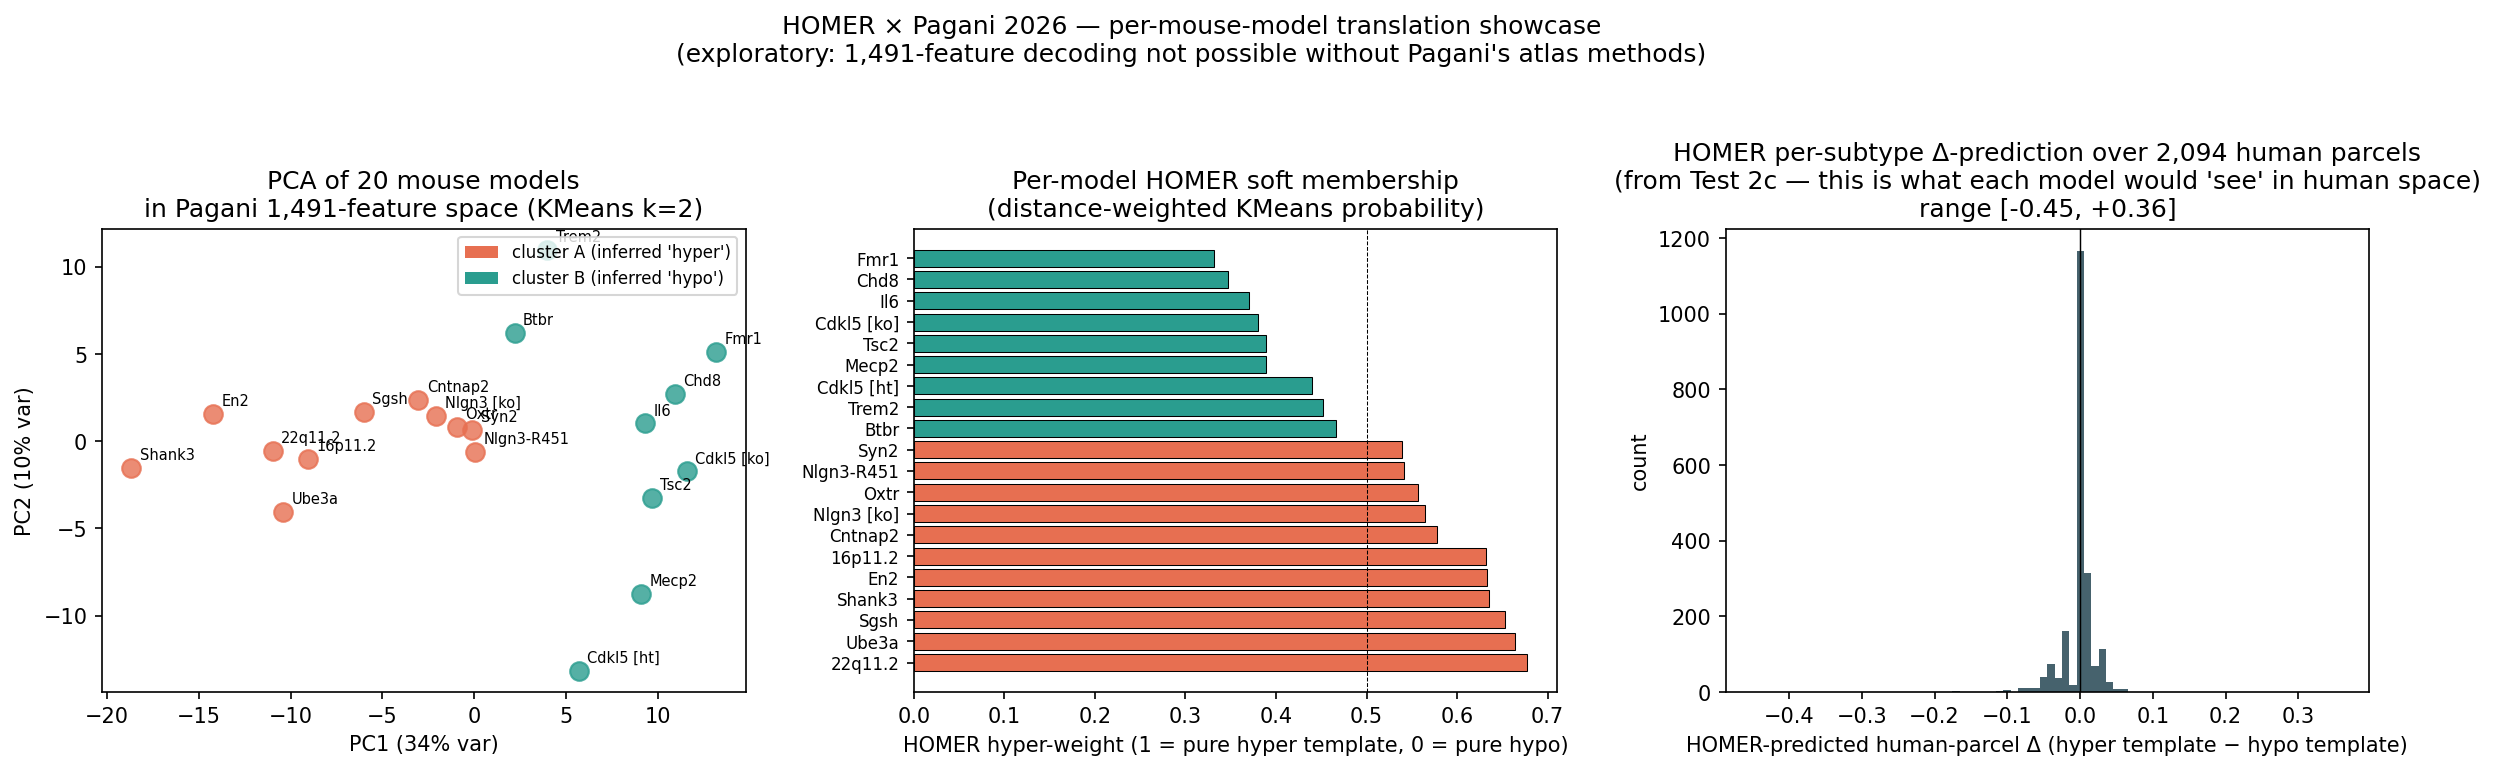

In [4]:
from IPython.display import Image, display
fig_path = ROOT / 'outputs/figures/pagani_per_model_translation.png'
if fig_path.exists():
    display(Image(str(fig_path)))
else:
    print('Run experiments/pagani_2026_per_model/02_plot.py to generate the figure.')


## What this showcase tells us

**At the per-subtype level** (where Test 2c lives), HOMER's predicted human-parcel Δ has a long tail (range +0.45 to −0.45 in arbitrary template units) concentrated in specific human regions (Subcortical, Limbic, Salience on the hyper side; Control, DorsAttn, DMN on the hypo side, per Test 2c results). This is real cross-species signal at r=+0.601 against Pagani's observed Δ.

**At the per-model level** the per-model HOMER soft-membership weights show the 20 models distributed continuously between the two templates — a few are strongly hyper-like (Sgsh, Ube3a, 22q11.2 in this analysis), a few are strongly hypo-like (Fmr1, Chd8, Tsc2), and most sit closer to the middle. **But this distribution reflects the model's position in the 1,491-feature space we couldn't fully decode** — it shouldn't be interpreted as a quantitative claim about which human ASD subtype each mouse model resembles.

**Future work to enable a real per-model translation.**

1. **Decode the 1,491 features.** Read Pagani's methods to identify exactly what they represent (Allen-CCFv3 parcellation? flattened FC upper triangle? ICA component scores?) and map to HOMER's 1,864-parcel atlas via centroid alignment.
2. **Once decoded**, for each mouse model, route its parcel-level perturbation through π → predicted human-parcel signature. This would replace subtype-average resolution with per-model resolution.
3. **Validate against ENIGMA / SFARI individual-subject FC maps** — currently no per-mouse-model human FC dataset exists publicly, so we'd need a different cross-species ground truth.

For full details: [`docs/03_results.md`](../docs/03_results.md). Code: `experiments/pagani_2026_per_model/`.
